# 🩺 Breast Ultrasound Image Segmentation using U-Net
### B.Tech Final Project — Department of ECE, IUST Kashmir
---
This notebook presents a **complete comparison** of two U-Net implementations for breast tumor segmentation:
- **Framework 1:** PyTorch (with BCE+Dice Loss, BatchNorm, Augmentation)
- **Framework 2:** TensorFlow/Keras (with BCE+Dice Loss, BatchNorm, Augmentation)

**Dataset:** BUSI (Breast Ultrasound Images) — Benign & Malignant classes


## 1. 📦 Imports & Setup


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, BatchNormalization, Activation, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanIoU, Precision, Recall

print(f'PyTorch version : {torch.__version__}')
print(f'TensorFlow version: {tf.__version__}')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device  : {device}')
print(f'TF GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')


PyTorch version : 2.12.1
TensorFlow version: 2.21.0
PyTorch device  : mps
TF GPU available: False


## 2. ⚙️ Configuration


In [2]:
# ── CHANGE THIS to your dataset location ──────────────────────────────────
DATASET_PATH = '/Users/abrarimtiyaz/Documents/VS Code/Dataset_BUSI_with_GT'
# ───────────────────────────────────────────────────────────────────────────

IMAGE_SIZE  = 128   # Input image size (128x128)
BATCH_SIZE  = 16    # Mini-batch size
EPOCHS      = 100   # Max epochs (early stopping will kick in earlier)
LR          = 1e-3  # Learning rate
PATIENCE    = 10    # Early stopping patience
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## 3. 📂 Data Loading


In [3]:
def load_image(path, size, is_mask=False):
    """Load, resize, and normalize a single image or mask."""
    image = cv2.imread(path)
    if image is None:
        raise ValueError(f'Failed to load: {path}')
    image = cv2.resize(image, (size, size))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = image / 255.0
    if is_mask:
        image = np.where(image > 0.5, 1.0, 0.0).astype('float32')
    return image.astype('float32')


def load_data(base_path, size):
    """
    Improved data loader:
    - Matches masks to images by filename
    - Combines multiple masks per image using np.maximum
    - Skips normal class (no tumor mask)
    """
    images, masks = [], []
    all_files  = glob(os.path.join(base_path, '**/*.png'), recursive=True)
    scan_images = sorted([f for f in all_files if '_mask' not in f])
    print(f'Found {len(scan_images)} ultrasound images. Loading...')

    for img_path in scan_images:
        base = os.path.splitext(img_path)[0]
        matched_masks = glob(f'{base}_mask*')
        if not matched_masks:
            continue  # skip normal class (no mask)
        img  = load_image(img_path, size, is_mask=False)
        combined_mask = np.zeros((size, size), dtype=np.float32)
        for mp in matched_masks:
            combined_mask = np.maximum(combined_mask, load_image(mp, size, is_mask=True))
        images.append(img)
        masks.append(combined_mask)

    X = np.array(images, dtype=np.float32)
    y = np.array(masks,  dtype=np.float32)
    print(f'Loaded  X: {X.shape}  |  y: {y.shape}')
    return X, y


X_raw, y_raw = load_data(DATASET_PATH, IMAGE_SIZE)


Found 780 ultrasound images. Loading...
Loaded  X: (780, 128, 128)  |  y: (780, 128, 128)


## 4. 🔍 Exploratory Data Analysis


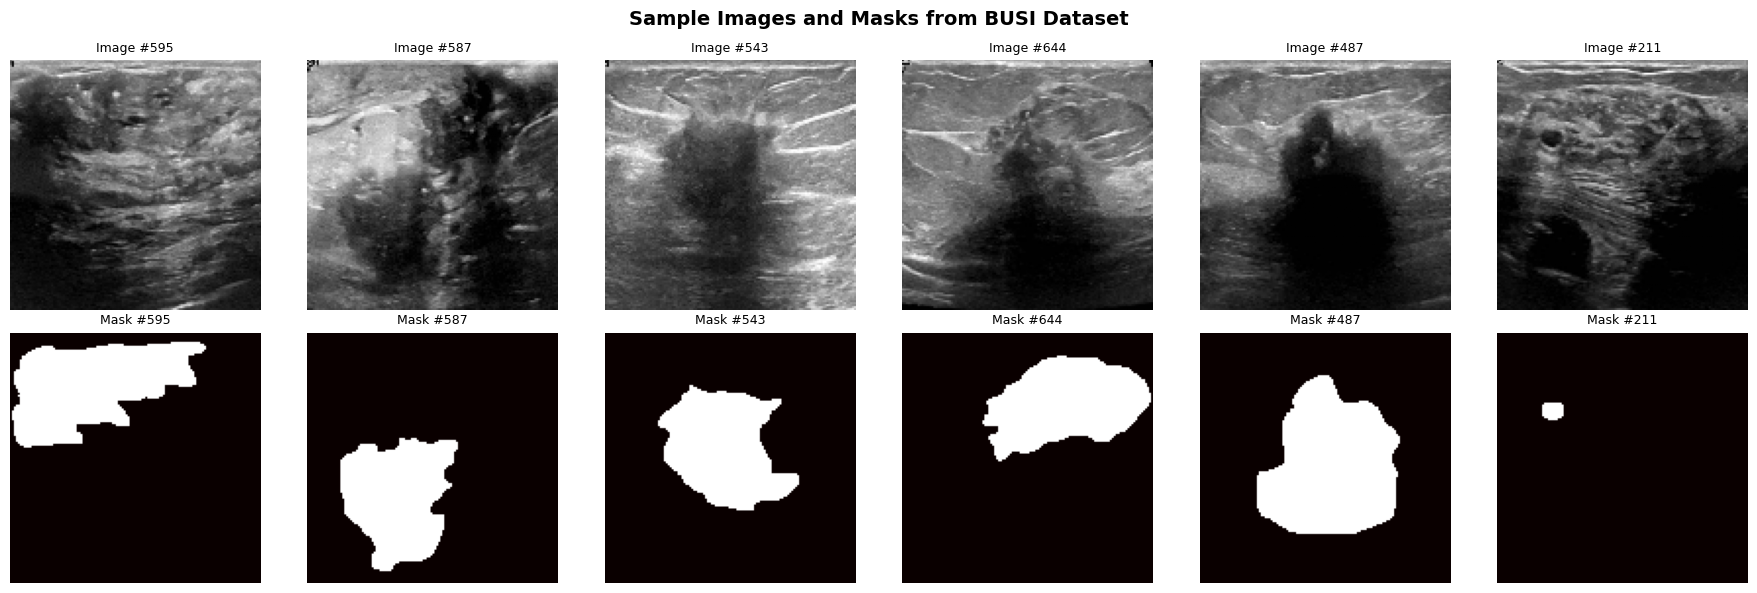


Dataset Statistics
  Total samples      : 780
  Avg tumor coverage : 7.83%
  Min tumor pixels   : 0
  Max tumor pixels   : 9216


In [4]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Images and Masks from BUSI Dataset', fontsize=14, fontweight='bold')
indices = np.random.choice(len(X_raw), 6, replace=False)
for col, idx in enumerate(indices):
    axes[0, col].imshow(X_raw[idx], cmap='gray')
    axes[0, col].set_title(f'Image #{idx}', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(y_raw[idx], cmap='hot')
    axes[1, col].set_title(f'Mask #{idx}', fontsize=9)
    axes[1, col].axis('off')
plt.tight_layout()
plt.show()

# Class statistics
tumor_pixels = y_raw.sum(axis=(1,2))
total_pixels = IMAGE_SIZE * IMAGE_SIZE
print(f'\nDataset Statistics')
print(f'  Total samples      : {len(X_raw)}')
print(f'  Avg tumor coverage : {100*tumor_pixels.mean()/total_pixels:.2f}%')
print(f'  Min tumor pixels   : {tumor_pixels.min():.0f}')
print(f'  Max tumor pixels   : {tumor_pixels.max():.0f}')


## 5. 🔄 Data Augmentation
Augmentation **triples** the training set using: horizontal flip, vertical flip, and 90° rotation.
Both image and mask are transformed together to keep them aligned.


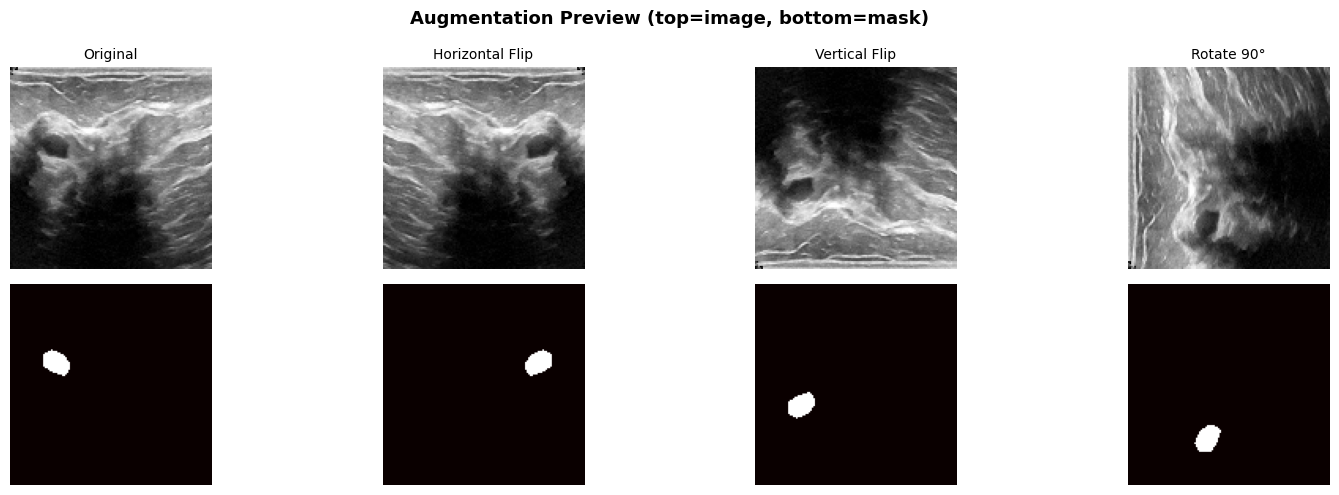

In [5]:
def augment_dataset(images, masks):
    """
    Apply horizontal flip, vertical flip, and 90-degree rotation.
    Returns augmented + original combined.
    """
    aug_imgs, aug_msks = [images.copy()], [masks.copy()]
    # Horizontal flip
    aug_imgs.append(images[:, :, ::-1].copy())
    aug_msks.append(masks[:, :, ::-1].copy())
    # Vertical flip
    aug_imgs.append(images[:, ::-1, :].copy())
    aug_msks.append(masks[:, ::-1, :].copy())
    # 90-degree rotation
    aug_imgs.append(np.rot90(images, k=1, axes=(1,2)).copy())
    aug_msks.append(np.rot90(masks,  k=1, axes=(1,2)).copy())
    return np.concatenate(aug_imgs, axis=0), np.concatenate(aug_msks, axis=0)


# Preview augmentations
idx = np.random.randint(len(X_raw))
sample_img, sample_msk = X_raw[idx], y_raw[idx]
aug_versions = [
    ('Original',         sample_img,                          sample_msk),
    ('Horizontal Flip',  sample_img[:, ::-1],                 sample_msk[:, ::-1]),
    ('Vertical Flip',    sample_img[::-1, :],                 sample_msk[::-1, :]),
    ('Rotate 90°',       np.rot90(sample_img),                np.rot90(sample_msk)),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
fig.suptitle('Augmentation Preview (top=image, bottom=mask)', fontsize=13, fontweight='bold')
for col, (title, img, msk) in enumerate(aug_versions):
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(title, fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].imshow(msk, cmap='hot')
    axes[1, col].axis('off')
plt.tight_layout()
plt.show()


## 6. ✂️ Data Splitting
Split: **70% Train → Augmented** | **15% Validation** | **15% Test** (no augmentation on val/test)


In [6]:
# Split raw data BEFORE augmentation to avoid data leakage
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED)

# Augment ONLY training data
X_train, y_train = augment_dataset(X_train_raw, y_train_raw)

# Shuffle training set
shuffle_idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

print(f'Train (after augmentation): {X_train.shape}')
print(f'Validation               : {X_val.shape}')
print(f'Test                     : {X_test.shape}')


Train (after augmentation): (2184, 128, 128)
Validation               : (117, 128, 128)
Test                     : (117, 128, 128)


---
## 7. 🔥 Framework 1: PyTorch U-Net


### 7.1 Dataset Class & DataLoaders


In [7]:
class BUSIDataset(Dataset):
    def __init__(self, images, masks):
        # Add channel dim for PyTorch: (N, 1, H, W)
        self.images = torch.tensor(images[:, np.newaxis, :, :], dtype=torch.float32)
        self.masks  = torch.tensor(masks[ :, np.newaxis, :, :], dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]


pt_train_loader = DataLoader(BUSIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
pt_val_loader   = DataLoader(BUSIDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
pt_test_loader  = DataLoader(BUSIDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)
print('DataLoaders ready.')


DataLoaders ready.


### 7.2 U-Net Architecture (with Batch Normalization)


In [8]:
class DoubleConv(nn.Module):
    """Two Conv2D layers each followed by BatchNorm + ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNetPyTorch(nn.Module):
    """
    U-Net for binary segmentation.
    Encoder: 1→16→32→64→128→256
    Decoder: 256→128→64→32→16→1
    """
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(1,   16)
        self.enc2 = DoubleConv(16,  32)
        self.enc3 = DoubleConv(32,  64)
        self.enc4 = DoubleConv(64, 128)
        self.bottleneck = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        # Decoder
        self.up4   = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4  = DoubleConv(256, 128)
        self.up3   = nn.ConvTranspose2d(128, 64,  2, stride=2)
        self.dec3  = DoubleConv(128, 64)
        self.up2   = nn.ConvTranspose2d(64,  32,  2, stride=2)
        self.dec2  = DoubleConv(64,  32)
        self.up1   = nn.ConvTranspose2d(32,  16,  2, stride=2)
        self.dec1  = DoubleConv(32,  16)
        self.out   = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([e4, self.up4(b)],  dim=1))
        d3 = self.dec3(torch.cat([e3, self.up3(d4)], dim=1))
        d2 = self.dec2(torch.cat([e2, self.up2(d3)], dim=1))
        d1 = self.dec1(torch.cat([e1, self.up1(d2)], dim=1))
        return self.out(d1)


pt_model = UNetPyTorch().to(device)
total_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f'PyTorch U-Net | Trainable Parameters: {total_params:,}')


PyTorch U-Net | Trainable Parameters: 1,942,289


### 7.3 Combined BCE + Dice Loss


In [9]:
def dice_loss_pt(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)
    p = probs.view(-1)
    t = targets.view(-1)
    intersection = (p * t).sum()
    return 1 - (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)

def bce_dice_loss_pt(logits, targets):
    bce  = nn.BCEWithLogitsLoss()(logits, targets)
    dice = dice_loss_pt(logits, targets)
    return 0.5 * bce + 0.5 * dice


### 7.4 Training Loop


Training PyTorch U-Net...
Epoch   1/100 | Train Loss: 0.6004 | Val Loss: 0.5392
Epoch  10/100 | Train Loss: 0.1829 | Val Loss: 0.2063
Epoch  20/100 | Train Loss: 0.1152 | Val Loss: 0.2079
Early stopping at epoch 26

Training complete. Best weights loaded.


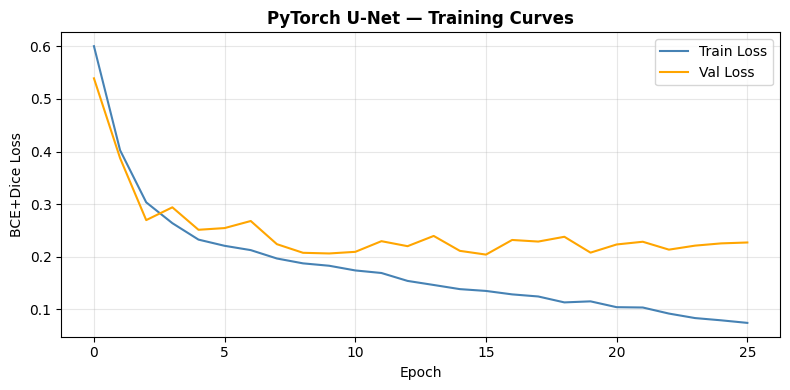

In [10]:
pt_optimizer = optim.Adam(pt_model.parameters(), lr=LR)
pt_scheduler = optim.lr_scheduler.ReduceLROnPlateau(pt_optimizer, patience=5, factor=0.5)

pt_train_losses, pt_val_losses = [], []
best_pt_val_loss = float('inf')
pt_patience_counter = 0
best_pt_weights = None

print('Training PyTorch U-Net...')
for epoch in range(EPOCHS):
    # ── Train ──
    pt_model.train()
    train_loss = 0.0
    for imgs, msks in pt_train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        pt_optimizer.zero_grad()
        loss = bce_dice_loss_pt(pt_model(imgs), msks)
        loss.backward()
        pt_optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(pt_train_loader.dataset)

    # ── Validate ──
    pt_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, msks in pt_val_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            val_loss += bce_dice_loss_pt(pt_model(imgs), msks).item() * imgs.size(0)
    val_loss /= len(pt_val_loader.dataset)

    pt_train_losses.append(train_loss)
    pt_val_losses.append(val_loss)
    pt_scheduler.step(val_loss)

    if val_loss < best_pt_val_loss:
        best_pt_val_loss = val_loss
        pt_patience_counter = 0
        torch.save(pt_model.state_dict(), 'best_pytorch_unet.pth')
    else:
        pt_patience_counter += 1
        if pt_patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

# Restore best weights
pt_model.load_state_dict(torch.load('best_pytorch_unet.pth', map_location=device))
print('\nTraining complete. Best weights loaded.')

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(pt_train_losses, label='Train Loss', color='steelblue')
plt.plot(pt_val_losses,   label='Val Loss',   color='orange')
plt.title('PyTorch U-Net — Training Curves', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('BCE+Dice Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.5 Evaluation — PyTorch


In [11]:
pt_model.eval()
all_preds_pt, all_true_pt = [], []

with torch.no_grad():
    for imgs, msks in pt_test_loader:
        imgs = imgs.to(device)
        probs = torch.sigmoid(pt_model(imgs))
        preds = (probs > 0.5).float().cpu().numpy()
        all_preds_pt.append(preds)
        all_true_pt.append(msks.numpy())

y_pred_pt = np.concatenate(all_preds_pt).flatten().astype(int)
y_true_pt = np.concatenate(all_true_pt).flatten().astype(int)

pt_iou  = jaccard_score(y_true_pt, y_pred_pt, zero_division=0)
pt_prec = precision_score(y_true_pt, y_pred_pt, zero_division=0)
pt_rec  = recall_score(y_true_pt,   y_pred_pt, zero_division=0)
pt_f1   = f1_score(y_true_pt,       y_pred_pt, zero_division=0)

print('── PyTorch U-Net Results ──────────────')
print(f'  Mean IoU  : {pt_iou:.4f}')
print(f'  Precision : {pt_prec:.4f}')
print(f'  Recall    : {pt_rec:.4f}')
print(f'  F1 Score  : {pt_f1:.4f}')


── PyTorch U-Net Results ──────────────
  Mean IoU  : 0.5740
  Precision : 0.7974
  Recall    : 0.6720
  F1 Score  : 0.7294


---
## 8. 🟣 Framework 2: TensorFlow / Keras U-Net


### 8.1 Architecture (with Batch Normalization)


In [12]:
def conv_block_tf(x, filters):
    """Two Conv2D layers with BatchNorm + ReLU."""
    x = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def encoder_block_tf(x, filters):
    skip = conv_block_tf(x, filters)
    pool = MaxPooling2D(2)(skip)
    return skip, pool

def decoder_block_tf(x, skip, filters):
    x = Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = concatenate([x, skip])
    x = conv_block_tf(x, filters)
    return x

def build_unet_keras(input_shape=(128, 128, 1)):
    inputs = Input(input_shape)
    s1, p1 = encoder_block_tf(inputs, 16)
    s2, p2 = encoder_block_tf(p1,     32)
    s3, p3 = encoder_block_tf(p2,     64)
    s4, p4 = encoder_block_tf(p3,    128)
    b      = conv_block_tf(p4,        256)    # Bottleneck
    d4     = decoder_block_tf(b,  s4, 128)
    d3     = decoder_block_tf(d4, s3,  64)
    d2     = decoder_block_tf(d3, s2,  32)
    d1     = decoder_block_tf(d2, s1,  16)
    outputs = Conv2D(1, 1, activation='sigmoid')(d1)
    return Model(inputs, outputs, name='UNet_Keras')

tf_model = build_unet_keras(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
tf_model.summary()


Model: "UNet_Keras"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        144 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,304 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,608 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,216 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,432 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 1,945,233 (7.42 MB)

 Trainable params: 1,942,289 (7.41 MB)

 Non-trainable params: 2,944 (11.50 KB)

### 8.2 BCE + Dice Loss for Keras


In [13]:
def dice_loss_tf(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def bce_dice_loss_tf(y_true, y_pred):
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss_tf(y_true, y_pred)
    return 0.5 * tf.reduce_mean(bce) + 0.5 * dice

def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-7) / (union + 1e-7)

tf_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=bce_dice_loss_tf,
    metrics=[iou_metric, 'accuracy']
)


### 8.3 Training


Training Keras U-Net...
Epoch 1/100


137/137 - 41s - 299ms/step - accuracy: 0.9103 - iou_metric: 0.3574 - loss: 0.5185 - val_accuracy: 0.9245 - val_iou_metric: 0.1673 - val_loss: 0.5572 - learning_rate: 0.0010
Epoch 2/100
137/137 - 42s - 309ms/step - accuracy: 0.9415 - iou_metric: 0.4660 - loss: 0.3551 - val_accuracy: 0.7174 - val_iou_metric: 0.1849 - val_loss: 1.1274 - learning_rate: 0.0010
Epoch 3/100


137/137 - 53s - 384ms/step - accuracy: 0.9502 - iou_metric: 0.5087 - loss: 0.2860 - val_accuracy: 0.9345 - val_iou_metric: 0.3235 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 4/100


137/137 - 53s - 387ms/step - accuracy: 0.9555 - iou_metric: 0.5451 - loss: 0.2506 - val_accuracy: 0.9508 - val_iou_metric: 0.3678 - val_loss: 0.3729 - learning_rate: 0.0010
Epoch 5/100


137/137 - 53s - 390ms/step - accuracy: 0.9589 - iou_metric: 0.5670 - loss: 0.2325 - val_accuracy: 0.9533 - val_iou_metric: 0.4160 - val_loss: 0.3244 - learning_rate: 0.0010
Epoch 6/100


137/137 - 55s - 405ms/step - accuracy: 0.9622 - iou_metric: 0.5954 - loss: 0.2140 - val_accuracy: 0.9655 - val_iou_metric: 0.6152 - val_loss: 0.2027 - learning_rate: 0.0010
Epoch 7/100
137/137 - 60s - 435ms/step - accuracy: 0.9658 - iou_metric: 0.6251 - loss: 0.1947 - val_accuracy: 0.9634 - val_iou_metric: 0.5486 - val_loss: 0.2428 - learning_rate: 0.0010
Epoch 8/100
137/137 - 57s - 415ms/step - accuracy: 0.9668 - iou_metric: 0.6359 - loss: 0.1883 - val_accuracy: 0.9647 - val_iou_metric: 0.5724 - val_loss: 0.2211 - learning_rate: 0.0010
Epoch 9/100
137/137 - 66s - 481ms/step - accuracy: 0.9692 - iou_metric: 0.6558 - loss: 0.1754 - val_accuracy: 0.9634 - val_iou_metric: 0.6082 - val_loss: 0.2115 - learning_rate: 0.0010
Epoch 10/100
137/137 - 68s - 497ms/step - accuracy: 0.9701 - iou_metric: 0.6675 - loss: 0.1691 - val_accuracy: 0.9494 - val_iou_metric: 0.5379 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 11/100

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487

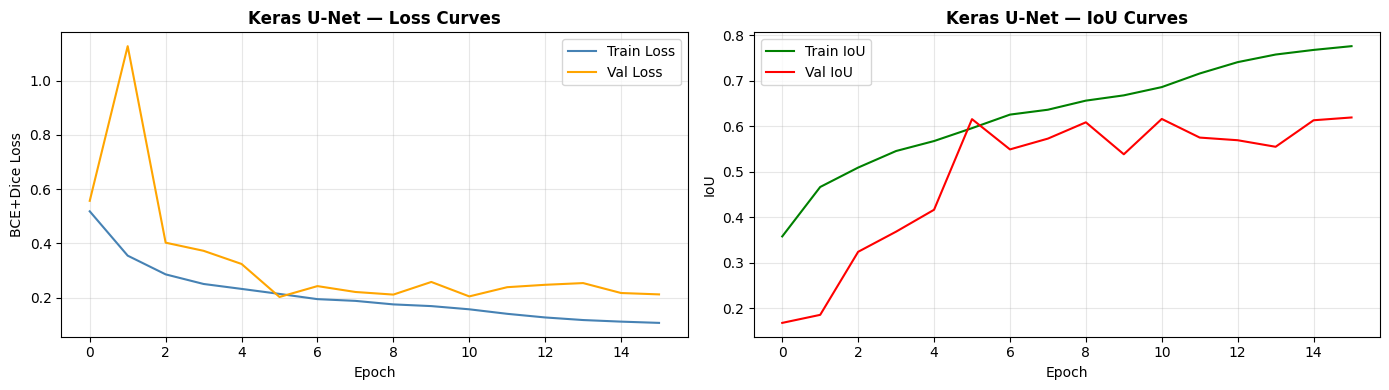

In [14]:
# Keras expects (N, H, W, C)
X_train_tf = X_train[..., np.newaxis]
y_train_tf = y_train[..., np.newaxis]
X_val_tf   = X_val[...,   np.newaxis]
y_val_tf   = y_val[...,   np.newaxis]
X_test_tf  = X_test[...,  np.newaxis]
y_test_tf  = y_test[...,  np.newaxis]

callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_keras_unet.h5', monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]

print('Training Keras U-Net...')
tf_history = tf_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(tf_history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(tf_history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Keras U-Net — Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE+Dice Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(tf_history.history['iou_metric'],     label='Train IoU', color='green')
axes[1].plot(tf_history.history['val_iou_metric'], label='Val IoU',   color='red')
axes[1].set_title('Keras U-Net — IoU Curves', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 8.4 Evaluation — Keras


In [15]:
y_pred_tf_raw = tf_model.predict(X_test_tf, verbose=0)
y_pred_tf_bin = (y_pred_tf_raw > 0.5).astype(int).flatten()
y_true_tf     = y_test_tf.astype(int).flatten()

tf_iou  = jaccard_score(y_true_tf, y_pred_tf_bin, zero_division=0)
tf_prec = precision_score(y_true_tf, y_pred_tf_bin, zero_division=0)
tf_rec  = recall_score(y_true_tf,   y_pred_tf_bin, zero_division=0)
tf_f1   = f1_score(y_true_tf,       y_pred_tf_bin, zero_division=0)

print('── Keras U-Net Results ────────────────')
print(f'  Mean IoU  : {tf_iou:.4f}')
print(f'  Precision : {tf_prec:.4f}')
print(f'  Recall    : {tf_rec:.4f}')
print(f'  F1 Score  : {tf_f1:.4f}')


── Keras U-Net Results ────────────────
  Mean IoU  : 0.5468
  Precision : 0.8012
  Recall    : 0.6326
  F1 Score  : 0.7070


---
## 9. 📊 Model Comparison


### 9.1 Metrics Table


   Metric  PyTorch  Keras/TF     Better
 Mean IoU   0.5740    0.5468  🔥 PyTorch
Precision   0.7974    0.8012 🔥 Keras/TF
   Recall   0.6720    0.6326  🔥 PyTorch
 F1 Score   0.7294    0.7070  🔥 PyTorch


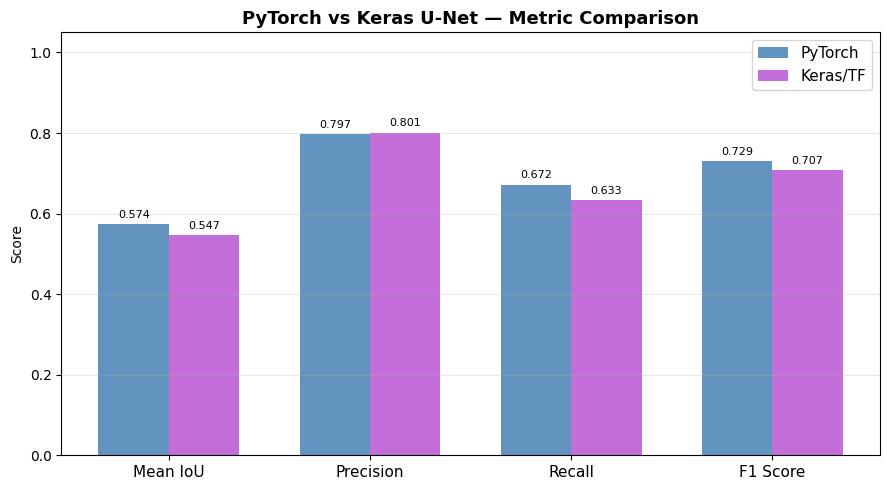

In [16]:
metrics_df = pd.DataFrame({
    'Metric'    : ['Mean IoU', 'Precision', 'Recall', 'F1 Score'],
    'PyTorch'   : [pt_iou,  pt_prec, pt_rec, pt_f1],
    'Keras/TF'  : [tf_iou,  tf_prec, tf_rec, tf_f1],
})
metrics_df['Better'] = metrics_df.apply(
    lambda r: '🔥 PyTorch' if r['PyTorch'] > r['Keras/TF'] else '🔥 Keras/TF', axis=1)
metrics_df[['PyTorch','Keras/TF']] = metrics_df[['PyTorch','Keras/TF']].round(4)
print(metrics_df.to_string(index=False))

# Bar chart
x = np.arange(4)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, metrics_df['PyTorch'],  width, label='PyTorch',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, metrics_df['Keras/TF'], width, label='Keras/TF', color='mediumorchid', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics_df['Metric'], fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score'); ax.set_title('PyTorch vs Keras U-Net — Metric Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout(); plt.show()


### 9.2 Visual Comparison of Predictions


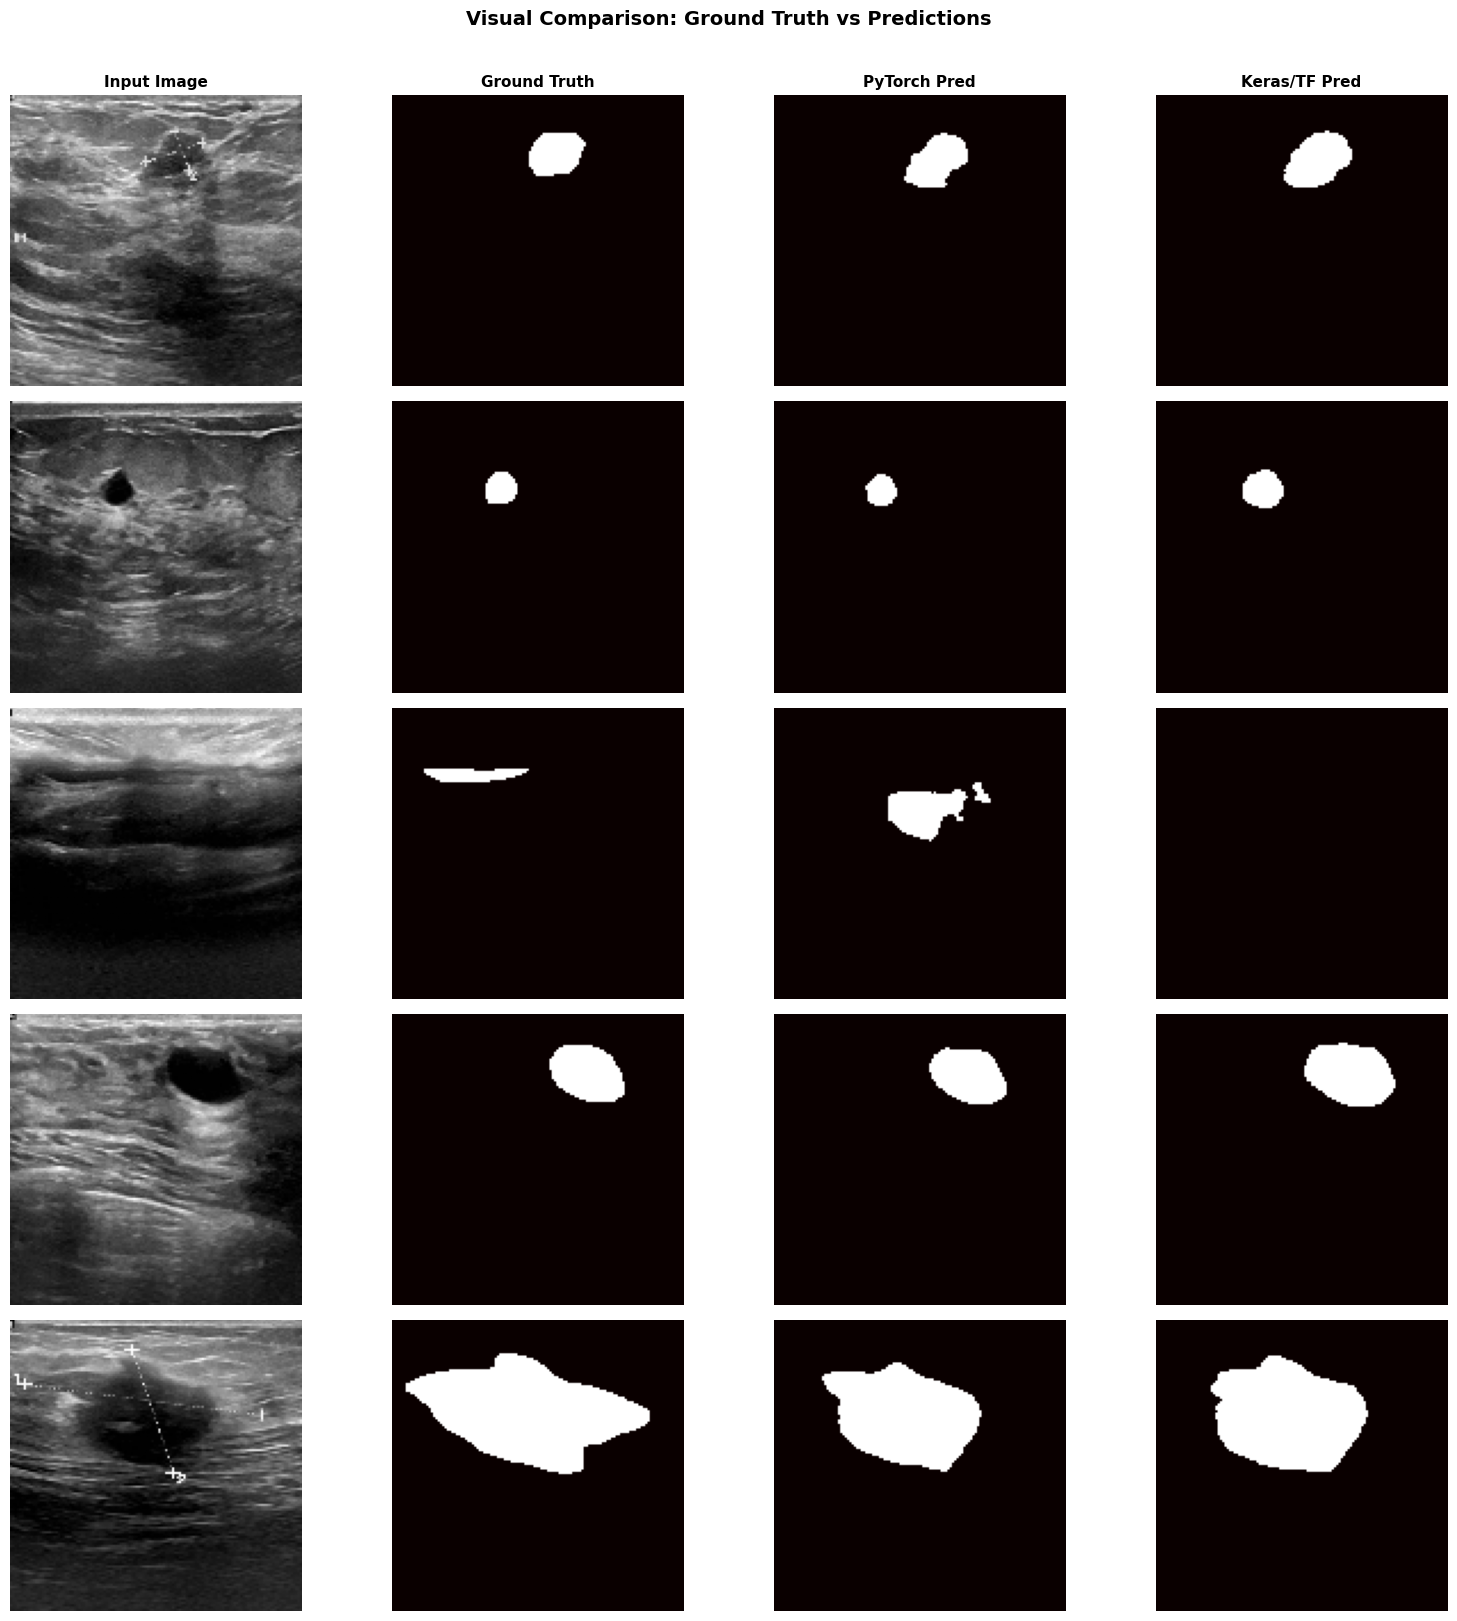

In [17]:
n_samples = 5
sample_idx = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 3.2))
fig.suptitle('Visual Comparison: Ground Truth vs Predictions', fontsize=14, fontweight='bold', y=1.01)
col_titles = ['Input Image', 'Ground Truth', 'PyTorch Pred', 'Keras/TF Pred']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=11)

pt_model.eval()
for row, idx in enumerate(sample_idx):
    img  = X_test[idx]
    mask = y_test[idx]

    # PyTorch prediction
    with torch.no_grad():
        inp_pt = torch.tensor(img[np.newaxis, np.newaxis]).to(device)
        pred_pt = torch.sigmoid(pt_model(inp_pt)).squeeze().cpu().numpy()
        pred_pt_bin = (pred_pt > 0.5).astype(float)

    # Keras prediction
    inp_tf  = img[np.newaxis, :, :, np.newaxis]
    pred_tf_bin = (tf_model.predict(inp_tf, verbose=0).squeeze() > 0.5).astype(float)

    axes[row, 0].imshow(img,         cmap='gray')
    axes[row, 1].imshow(mask,        cmap='hot')
    axes[row, 2].imshow(pred_pt_bin, cmap='hot')
    axes[row, 3].imshow(pred_tf_bin, cmap='hot')
    for ax in axes[row]: ax.axis('off')

plt.tight_layout(); plt.show()


### 9.3 Overlay Visualization (Image + Predicted Mask)


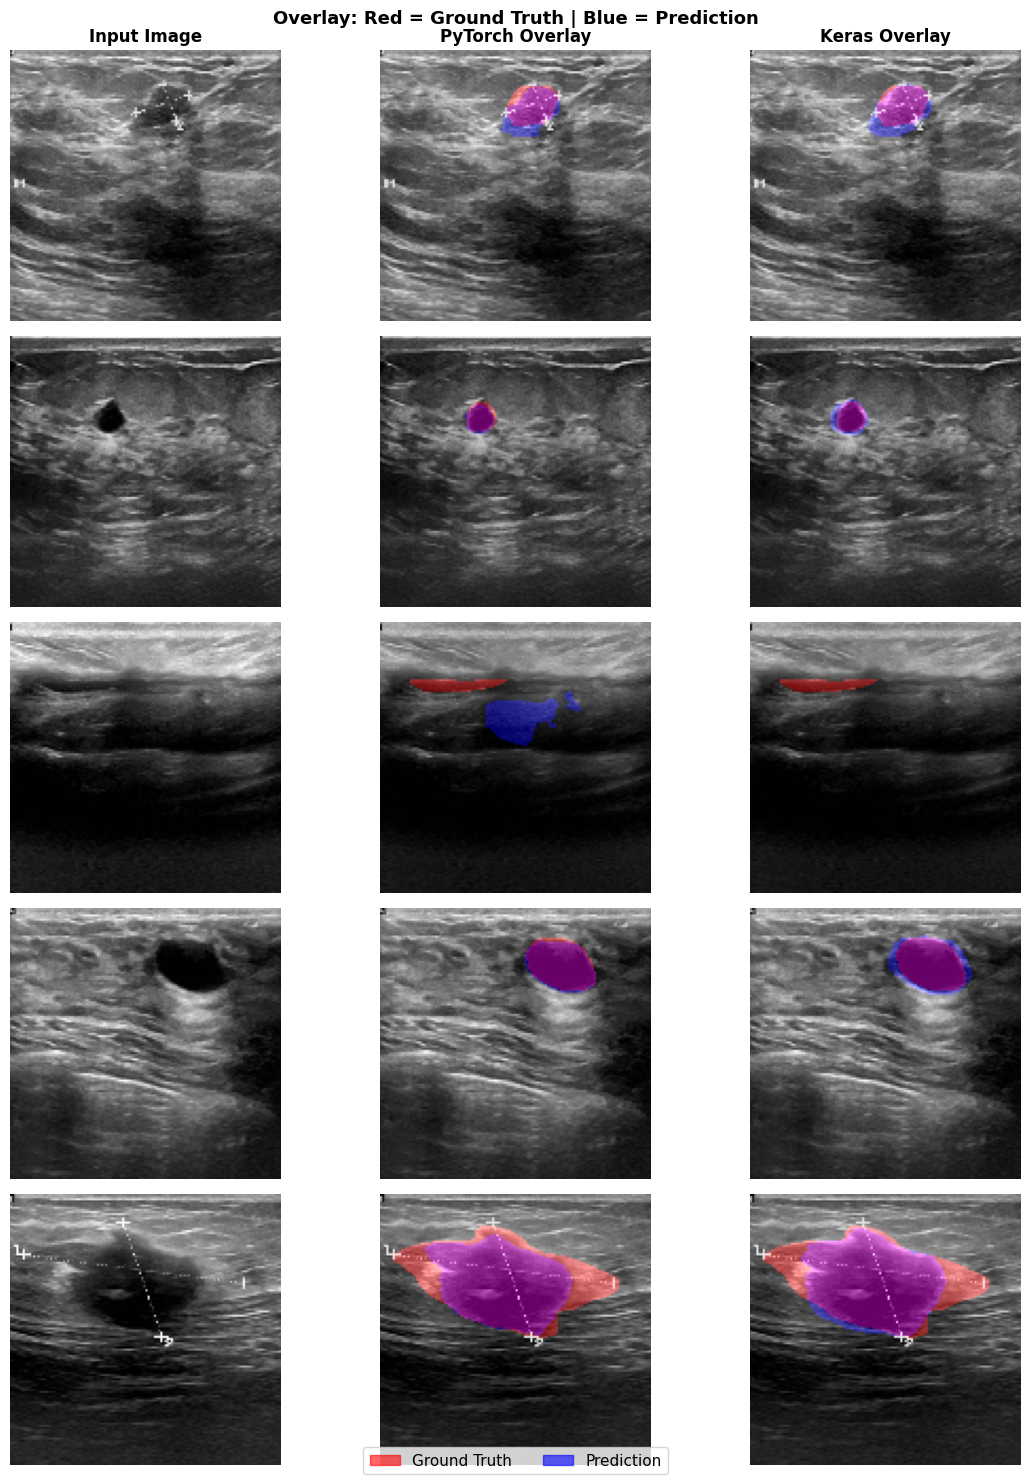

In [18]:
fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))
fig.suptitle('Overlay: Red = Ground Truth | Blue = Prediction', fontsize=13, fontweight='bold')

for row, idx in enumerate(sample_idx):
    img  = X_test[idx]
    mask = y_test[idx]

    with torch.no_grad():
        inp_pt = torch.tensor(img[np.newaxis, np.newaxis]).to(device)
        pred_pt_bin = (torch.sigmoid(pt_model(inp_pt)).squeeze().cpu().numpy() > 0.5).astype(float)

    inp_tf = img[np.newaxis, :, :, np.newaxis]
    pred_tf_bin = (tf_model.predict(inp_tf, verbose=0).squeeze() > 0.5).astype(float)

    def overlay(img, gt, pred):
        rgb = np.stack([img]*3, axis=-1)
        rgb[:,:,0] = np.clip(rgb[:,:,0] + 0.4 * gt,   0, 1)  # Red = GT
        rgb[:,:,2] = np.clip(rgb[:,:,2] + 0.4 * pred, 0, 1)  # Blue = Pred
        return rgb

    axes[row, 0].imshow(img, cmap='gray'); axes[row, 0].axis('off')
    if row == 0: axes[row, 0].set_title('Input Image', fontweight='bold')
    axes[row, 1].imshow(overlay(img, mask, pred_pt_bin)); axes[row, 1].axis('off')
    if row == 0: axes[row, 1].set_title('PyTorch Overlay', fontweight='bold')
    axes[row, 2].imshow(overlay(img, mask, pred_tf_bin)); axes[row, 2].axis('off')
    if row == 0: axes[row, 2].set_title('Keras Overlay', fontweight='bold')

red_patch  = mpatches.Patch(color='red',  alpha=0.6, label='Ground Truth')
blue_patch = mpatches.Patch(color='blue', alpha=0.6, label='Prediction')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2, fontsize=11)
plt.tight_layout(); plt.show()


---
## 10. 💾 Save Models


In [19]:
# PyTorch — already saved during training as 'best_pytorch_unet.pth'
# Final explicit save:
torch.save(pt_model.state_dict(), 'final_pytorch_unet.pth')
print('PyTorch model saved: final_pytorch_unet.pth')

# Keras — already saved during training as 'best_keras_unet.h5'
tf_model.save('final_keras_unet.h5')
print('Keras   model saved: final_keras_unet.h5')


PyTorch model saved: final_pytorch_unet.pth
Keras   model saved: final_keras_unet.h5


---
## Summary

| Feature | PyTorch | Keras/TF |
|-|-|-|
| Loss | BCE + Dice | BCE + Dice |
| Batch Normalization | ✅ | ✅ |
| Data Augmentation | ✅ (×4) | ✅ (×4) |
| Early Stopping | ✅ | ✅ |
| LR Scheduler | ReduceLROnPlateau | ReduceLROnPlateau |
| Skip Connections | ✅ | ✅ |

**Dataset:** BUSI — Breast Ultrasound Images (Benign + Malignant)

**Department of ECE, IUST Kashmir — B.Tech Final Project**
